W celu stworzenia narzędzia oceniającego wiarygodność zadanego tekstu, wykorzystamy zbiór danych składający się z części obserwacji ze zbioru *ISOT Fake News Dataset* [[1](https://onlinelibrary.wiley.com/doi/abs/10.1002/spy2.9), [2](https://link.springer.com/chapter/10.1007/978-3-319-69155-8_9)] oraz zescrapowanych artykułów pochodzących zarówno z rzetelnych źródeł, jak i tych mniej wiarygodnych.

Pierwszy zbiór danych składa się z wiarygodnych artykułów pochodzących z portalu *Reauters*, a artykuły zawierające fake newsu pochodzą z różnych źródeł i zostały oznaczone jako niewiarygodne przez specjalistów z *Politifact* - organizacji fact-checkingowej z USA. Dane zostały zebrane za okres 2016 do 2017 roku.

Wspomiany zbiór danych został wzbogacony o nowe dane, które zostaly zescrapowane z rzetelnych źródeł, przykładowo, takich jak *NPR* lub *AP News* oraz źródeł uznanych przez kolejną organizację fact-checkingową *Media Bias/Fact Check* za niegodne zaufania. Głównym celem dodania tych danych była potrzeba uodpornienia modelu na nowoczesny tekst, który nawet w przypadku renomowanych portali, często jest pisany w oparciu o AI. Zakładamy, że fragmenty generowanego tekstu mogą znacząco wpływać na cechy opisujące dany artykuł, co może kontrastować z wartościami dla starszych tekstów. Użycie AI w generowaniu tekstu może być jeszcze większe dla nierzetelnych portali, przez co potencjalnie mogą się one jeszcze bardziej różnić względem starszych fake newsów. 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
import re
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

In [2]:
nltk.download('stopwords', quiet=True)

True

In [3]:
def prep_word_count(df: pd.DataFrame, text_col: str) -> pd.DataFrame:
    """
    Filtruje puste teksty i dodaje kolumnę 'word_count' z liczbą słów.
    Zwraca bezpieczną kopię ramki danych.
    """
    clean_df = df.copy()
    clean_df = clean_df[clean_df[text_col].fillna("").str.split().str.len() > 0]
    clean_df['word_count'] = clean_df[text_col].str.split().str.len()
    
    return clean_df

In [4]:
isot_fake = pd.read_csv("../data/raw/ISOT/Fake.csv")
isot_true = pd.read_csv("../data/raw/ISOT/True.csv")

In [5]:
isot_fake = isot_fake[isot_fake["text"].str.strip() != '']
isot_true = isot_true[isot_true["text"].str.strip() != '']

In [6]:
isot_fake['text'] = isot_fake['text'].str.strip() # Usuwanie białych znaków z początku i końca tekstu
isot_true['text'] = isot_true['text'].str.strip()

In [7]:
isot_fake.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [8]:
isot_true.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [9]:
isot_fake.shape[0], isot_true.shape[0]

(22851, 21416)

Zgodnie z informacją od autorów zbioru *ISOT* wszystkie rzetelne artykuły pochodzą z portalu *Reuters*. Zauważamy, że bardzo często zaczynają się one od schametu `MIASTO (REUTERS) - `, a następnie później mamy właściwą treść artykułu. Pozbędziemy się tych wstępów, ze względu na to, że zostawienie mogłoby znacząco zbiasować model. 

In [10]:
isot_true["text"].head(20)

0     WASHINGTON (Reuters) - The head of a conservat...
1     WASHINGTON (Reuters) - Transgender people will...
2     WASHINGTON (Reuters) - The special counsel inv...
3     WASHINGTON (Reuters) - Trump campaign adviser ...
4     SEATTLE/WASHINGTON (Reuters) - President Donal...
5     WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...
6     WEST PALM BEACH, Fla (Reuters) - President Don...
7     The following statements were posted to the ve...
8     The following statements were posted to the ve...
9     WASHINGTON (Reuters) - Alabama Secretary of St...
10    (Reuters) - Alabama officials on Thursday cert...
11    NEW YORK/WASHINGTON (Reuters) - The new U.S. t...
12    The following statements were posted to the ve...
13    The following statements were posted to the ve...
14    (In Dec. 25 story, in second paragraph, correc...
15    (Reuters) - A lottery drawing to settle a tied...
16    WASHINGTON (Reuters) - A Georgian-American bus...
17    The following statements were posted to th

In [11]:
isot_true["text"] = isot_true["text"].str.replace(r'^.*?\([Rr]euters\)\s*-\s*', '', regex=True) # Usuwamy nagłówek

In [12]:
isot_true["text"].head(6)

0    The head of a conservative Republican faction ...
1    Transgender people will be allowed for the fir...
2    The special counsel investigation of links bet...
3    Trump campaign adviser George Papadopoulos tol...
4    President Donald Trump called on the U.S. Post...
5    The White House said on Friday it was set to k...
Name: text, dtype: str

Zauważamy również kolejny typ tekstu - tweety zaczynają się oraz kończą zgodnie z okresloną formułką, również musimy je znormalizować.

In [13]:
print(isot_true["text"][13])

The following statements were posted to the verified Twitter accounts of U.S. President Donald Trump, @realDonaldTrump and @POTUS.  The opinions expressed are his own. Reuters has not edited the statements or confirmed their accuracy.  @realDonaldTrump : - “On 1/20 - the day Trump was inaugurated - an estimated 35,000 ISIS fighters held approx 17,500 square miles of territory in both Iraq and Syria. As of 12/21, the U.S. military estimates the remaining 1,000 or so fighters occupy roughly 1,900 square miles...” via @jamiejmcintyre  [1749 EST] - Just left West Palm Beach Fire & Rescue #2. Met with great men and women as representatives of those who do so much for all of us. Firefighters, paramedics, first responders - what amazing people they are! [1811 EST] - “On 1/20 - the day Trump was inaugurated - an estimated 35,000 ISIS fighters held approx 17,500 square miles of territory in both Iraq and Syria. As of 12/21, the U.S. military est the remaining 1,000 or so fighters occupy roughly

In [14]:
isot_true["text"] = isot_true["text"].str.replace(r'(?i)the following statements\s+were posted.*?their accuracy\.', '', regex=True) # usunięcie początkowej informacji
isot_true['text'] = isot_true['text'].str.replace(r'\[\d{4}\s+[A-Z]{3,4}\]', '', regex=True) # usunięcie znaczników czasu
isot_true['text'] = isot_true['text'].str.replace(r'(?i)--\s*source link:.*', '', regex=True) # usunięcie stopki

In [15]:
print(isot_true["text"][13])

  @realDonaldTrump : - “On 1/20 - the day Trump was inaugurated - an estimated 35,000 ISIS fighters held approx 17,500 square miles of territory in both Iraq and Syria. As of 12/21, the U.S. military estimates the remaining 1,000 or so fighters occupy roughly 1,900 square miles...” via @jamiejmcintyre   - Just left West Palm Beach Fire & Rescue #2. Met with great men and women as representatives of those who do so much for all of us. Firefighters, paramedics, first responders - what amazing people they are!  - “On 1/20 - the day Trump was inaugurated - an estimated 35,000 ISIS fighters held approx 17,500 square miles of territory in both Iraq and Syria. As of 12/21, the U.S. military est the remaining 1,000 or so fighters occupy roughly 1,900 square miles..” @jamiejmcintyre @dcexaminer  - "Arrests of MS-13 Members, Associates Up 83% Under Trump" bit.ly/2liRH3b  


In [16]:
isot_true['text'] = isot_true['text'].str.replace(r'http[s]?://\S+|www\.\S+|bit\.ly/\S+', '[LINK]', regex=True) # zastąpienie linków symbolem [LINK]

In [17]:
print(isot_true["text"][13])

  @realDonaldTrump : - “On 1/20 - the day Trump was inaugurated - an estimated 35,000 ISIS fighters held approx 17,500 square miles of territory in both Iraq and Syria. As of 12/21, the U.S. military estimates the remaining 1,000 or so fighters occupy roughly 1,900 square miles...” via @jamiejmcintyre   - Just left West Palm Beach Fire & Rescue #2. Met with great men and women as representatives of those who do so much for all of us. Firefighters, paramedics, first responders - what amazing people they are!  - “On 1/20 - the day Trump was inaugurated - an estimated 35,000 ISIS fighters held approx 17,500 square miles of territory in both Iraq and Syria. As of 12/21, the U.S. military est the remaining 1,000 or so fighters occupy roughly 1,900 square miles..” @jamiejmcintyre @dcexaminer  - "Arrests of MS-13 Members, Associates Up 83% Under Trump" [LINK]  


Zbiór `True` po transformacjach:

In [18]:
isot_true.head(10)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",The head of a conservative Republican faction ...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,Transgender people will be allowed for the fir...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,The special counsel investigation of links bet...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,Trump campaign adviser George Papadopoulos tol...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,President Donald Trump called on the U.S. Post...,politicsNews,"December 29, 2017"
5,"White House, Congress prepare for talks on spe...",The White House said on Friday it was set to k...,politicsNews,"December 29, 2017"
6,"Trump says Russia probe will be fair, but time...",President Donald Trump said on Thursday he bel...,politicsNews,"December 29, 2017"
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,@realDonaldTrump : - While the Fake News lov...,politicsNews,"December 29, 2017"
8,Trump on Twitter (Dec 28) - Global Warming,"@realDonaldTrump : - Together, we are MAKING...",politicsNews,"December 29, 2017"
9,Alabama official to certify Senator-elect Jone...,Alabama Secretary of State John Merrill said h...,politicsNews,"December 28, 2017"


In [19]:
isot_fake['text'].head(15)

0     Donald Trump just couldn t wish all Americans ...
1     House Intelligence Committee Chairman Devin Nu...
2     On Friday, it was revealed that former Milwauk...
3     On Christmas day, Donald Trump announced that ...
4     Pope Francis used his annual Christmas Day mes...
5     The number of cases of cops brutalizing and ki...
6     Donald Trump spent a good portion of his day a...
7     In the wake of yet another court decision that...
8     Many people have raised the alarm regarding th...
9     Just when you might have thought we d get a br...
10    A centerpiece of Donald Trump s campaign, and ...
11    Republicans are working overtime trying to sel...
12    Republicans have had seven years to come up wi...
13    The media has been talking all day about Trump...
14    Abigail Disney is an heiress with brass ovarie...
Name: text, dtype: str

In [20]:
isot_fake['text'] = isot_fake['text'].str.replace(r'http[s]?://\S+|www\.\S+|bit\.ly/\S+', '[LINK]', regex=True)

Przejdziemy do analizy liczby słów per artykuł w zestawieniu na dane fake'owe oraz rzetelne.

In [21]:
def get_word_count_stats(df: pd.DataFrame) -> dict:
    df_word_count = prep_word_count(df, "text")
    
    stats = {
        "mean": float(df_word_count['word_count'].mean().round(2)),
        "median": float(df_word_count['word_count'].median()),
        "std": float(df_word_count['word_count'].std().round(2)),
        "min": int(df_word_count['word_count'].min()),
        "max": int(df_word_count['word_count'].max())
    }
    
    return stats

In [22]:
get_word_count_stats(isot_fake)

{'mean': 434.87, 'median': 369.0, 'std': 407.81, 'min': 1, 'max': 8135}

In [23]:
get_word_count_stats(isot_true)

{'mean': 382.17, 'median': 356.0, 'std': 274.01, 'min': 12, 'max': 5170}

Już na poziomie podstawowych statystyk opisowych zauważamy znaczące różnice - nierzetelne artykuły są średnio znacząco dłuższe oraz bardziej rozproszone względem średniej długości.    

In [24]:
def plot_word_count_density(df: pd.DataFrame):
    
    plot_df = prep_word_count(df, "text")
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(6, 4))
    max_words = plot_df['word_count'].max()

    sns.kdeplot(
        data=plot_df, 
        x="word_count", 
        fill=True, 
        alpha=0.5, 
        linewidth=2,
        color="royalblue"
    )
    max
    plt.axvline(
        x=max_words, 
        color='red', 
        linestyle='--', 
        linewidth=2, 
        label=f'Maksymalna długość słów'
    )

    plt.title("Rozkład liczby słów w artykułach", fontsize=13)
    plt.xlabel("Liczba słów")
    plt.ylabel("Gęstość")
    
    plt.legend(loc='upper right', frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()

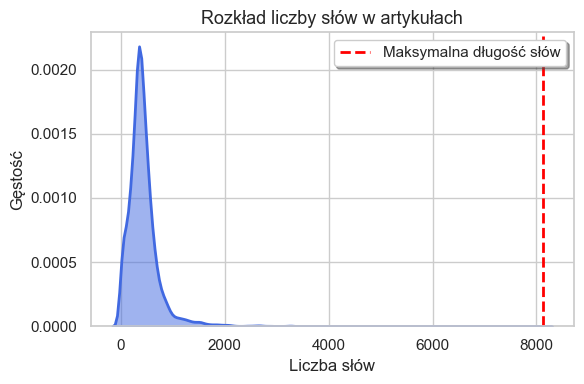

In [25]:
plot_word_count_density(isot_fake)

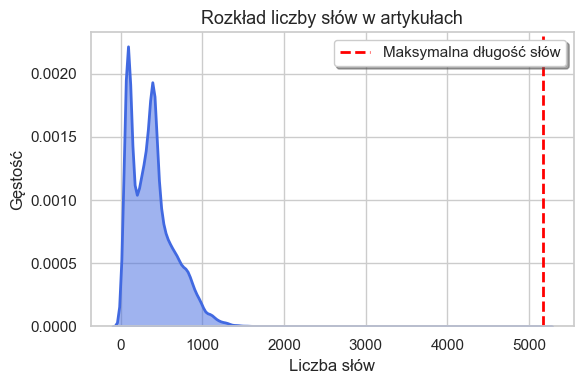

In [26]:
plot_word_count_density(isot_true)

Oba rozkałady są prawostronnie asymetryczne, z długimi ogonami. Wyraźna bimodalność rozkładu długości artykułów rzetelnych może oznaczać, że na populację składają się głównie krótsze treści (tweety) oraz dłuższe, charakterystczne dla typowych artykułów. 

In [27]:
def get_top_ngrams(text_series, top_n: int = 10, ngram_size: int = 2):

    stop_words = set(stopwords.words('english'))
    all_ngrams = []
    
    for text in text_series.dropna():
        text = str(text)
        text = re.sub(r'(?<!\w)([a-zA-Z])\.', r'\1', text)
        
        text = text.lower()
        words = re.findall(r'\b[a-z]+\b', text)
        
        # Filtrowanie stopwordsów
        filtered_words = [word for word in words if word not in stop_words]
        
        if ngram_size == 1:
            all_ngrams.extend(filtered_words)
        else:
            ngram_tuples = list(ngrams(filtered_words, ngram_size))
            ngram_strings = [" ".join(gram) for gram in ngram_tuples]
            all_ngrams.extend(ngram_strings)
            
    ngram_counts = Counter(all_ngrams)
    
    df_results = pd.DataFrame(
        ngram_counts.most_common(top_n), 
        columns=['ngram', 'frequency']
    )
    
    return df_results

In [28]:
get_top_ngrams(isot_true['text'], top_n = 20, ngram_size=2)

,ngram,frequency
0,united states,12204
1,donald trump,10040
2,white house,8417
3,president donald,5835
4,north korea,5658
5,prime minister,4163
6,said statement,3927
7,new york,3818
8,us president,3791
9,told reuters,3495


Najczęściej występujące bigramy w rzetelnch tesktach, to głownie nazwy stanowisk, państw oraz cytowania. 

In [29]:
get_top_ngrams(isot_fake['text'], top_n = 20, ngram_size=2)

,ngram,frequency
0,donald trump,14129
1,featured image,7586
2,hillary clinton,7249
3,white house,6742
4,united states,6663
5,image via,6328
6,twitter com,6222
7,pic twitter,6147
8,new york,4351
9,president obama,4082


W przypadku nierzetelnych newsów dominują bigramy odnoszące się do linków do social mediów oraz zdjęć

In [30]:
def print_word_cloud(text_series):
    text_to_cloud = " ".join(text_series.dropna().astype(str))

    wordcloud = WordCloud(
        width=1000, 
        height=600, 
        background_color='white', 
        colormap='magma', 
        max_words=50
    ).generate(text_to_cloud)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

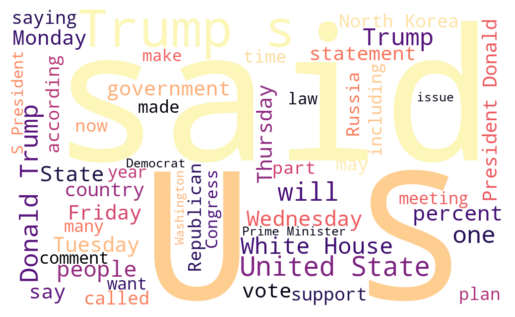

In [31]:
print_word_cloud(isot_true['text'])

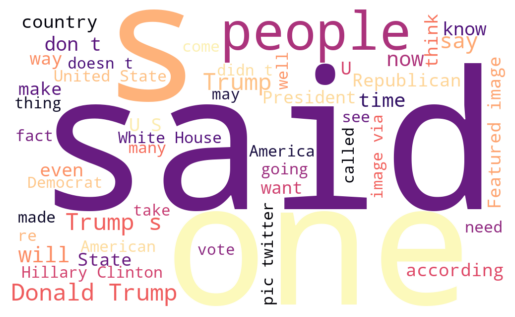

In [32]:
print_word_cloud(isot_fake['text'])

## Analiza stworzonego zbioru danych

In [33]:
scraped_true = pd.read_csv("../data/raw/newsapi_ai_era/reliable_news_api.csv")
scraped_fake = pd.read_csv("../data/raw/newsapi_ai_era/unreliable_news_api.csv")

In [34]:
scraped_true = scraped_true[scraped_true["text"].str.strip() != '']
scraped_fake = scraped_fake[scraped_fake["text"].str.strip() != '']

In [35]:
scraped_true['text'] = scraped_true['text'].str.strip()
scraped_fake['text'] = scraped_fake['text'].str.strip()

In [36]:
scraped_true.isna().sum()

text               0
label              0
source_category    0
publisher          0
dtype: int64

In [37]:
scraped_fake.isna().sum()

text               0
label              0
source_category    0
publisher          0
dtype: int64

In [38]:
scraped_fake.shape[0], scraped_true.shape[0]

(616, 596)

In [39]:
scraped_fake['publisher'].value_counts()

publisher
New York Post          295
Americanthinker.com    148
Breitbart News         129
Activistpost.com        28
Wnd.com                 15
Zerohedge.com            1
Name: count, dtype: int64

In [40]:
scraped_true['publisher'].value_counts()

publisher
NPR                 270
CBS News            220
CNBC                 63
Associated Press     43
Name: count, dtype: int64

In [41]:
scraped_fake.groupby('publisher').head(3).sort_values('publisher')

,text,label,source_category,publisher
25,Today is first day of the World Health Organiz...,1,news_api,Activistpost.com
26,"I gotta be honest with you, guys. The reason A...",1,news_api,Activistpost.com
27,The world is changing. The once dominant imper...,1,news_api,Activistpost.com
0,"On May 5, 2026, without fanfare, the Intergove...",1,news_api,Americanthinker.com
1,"The global managerial class of bureaucrats, ba...",1,news_api,Americanthinker.com
2,There has been a huge shift within the public ...,1,news_api,Americanthinker.com
13,President Donald Trump criticized Democrats on...,1,news_api,Breitbart News
14,Star Wars star and long-time climate doomer Ha...,1,news_api,Breitbart News
15,The United Nations’ Climate Panel admitted its...,1,news_api,Breitbart News
10,See more of our coverage in your search result...,1,news_api,New York Post


W przekroju per publisher widzimy, że artykuły z tabloidu *New York Post* mają charakterystyczny nagłówek, który możemy łatwo usunąć w processingu. 

In [42]:
scraped_fake[scraped_fake['publisher'] == 'New York Post'].head(6)

,text,label,source_category,publisher
10,See more of our coverage in your search result...,1,news_api,New York Post
11,See more of our coverage in your search result...,1,news_api,New York Post
12,See more of our coverage in your search result...,1,news_api,New York Post
35,See more of our coverage in your search result...,1,news_api,New York Post
36,See more of our coverage in your search result...,1,news_api,New York Post
37,See more of our coverage in your search result...,1,news_api,New York Post


In [43]:
scraped_fake['text'][35]

'See more of our coverage in your search results. Apocalyptic climate-change predictions were box-office gold for Hollywood but they did untold damage to the public psyche, economy and the average man’s pocketbook. Now the United Nations’ influential climate change committee has quietly discarded the dire temperature-rise scenarios used in two previous reports predicting horrific consequences of global warming if greenhouse emissions weren’t curbed. For years, lefty outfits — based on dubious climate science — screamed about the coming climate catastrophe: The New York Times warned that “Climate Change Is Harming The Planet Faster Than We Can Adapt,” “Climate Change Is Speeding Toward Catastrophe” and “A Hotter Future Is Certain.” Rep. Alexandria Ocasio-Cortez (D-NY) insisted the world would end by 2030 if we didn’t address climate change — by which she meant waste trillions on the Green New Deal and return to Stone Age-style living. Democrats went full-tilt in accepting the UN-backed 

In [44]:
scraped_fake['text'] = scraped_fake['text'].str.replace(r'(?i)^see more of our coverage in your search results\.?\s*', '', regex=True)

In [45]:
scraped_fake[scraped_fake['publisher'] == 'New York Post'].head(6)

,text,label,source_category,publisher
10,This California town wants to reverse its woke...,1,news_api,New York Post
11,"Cuteness, times three. An endangered red ruffe...",1,news_api,New York Post
12,The California Chamber of Commerce has endorse...,1,news_api,New York Post
35,Apocalyptic climate-change predictions were bo...,1,news_api,New York Post
36,It’s so easy and comfortable being a liberal: ...,1,news_api,New York Post
37,A progressive cult-like movement known as Effe...,1,news_api,New York Post


In [46]:
scraped_true.groupby('publisher').head(3).sort_values('publisher')

,text,label,source_category,publisher
45,Add AP News as your preferred source to see mo...,0,news_api,Associated Press
63,Add AP News as your preferred source to see mo...,0,news_api,Associated Press
73,Add AP News as your preferred source to see mo...,0,news_api,Associated Press
19,We may receive commissions from some links to ...,0,news_api,CBS News
20,We may receive commissions from some links to ...,0,news_api,CBS News
21,As the globe transitions into an El Niño clima...,0,news_api,CBS News
66,Philippines' Secretary of National Defense Gil...,0,news_api,CNBC
67,President Donald Trump led a ceremony swearing...,0,news_api,CNBC
68,In this article KER-FR PNDRY PNDRY HNNMY HMRZF...,0,news_api,CNBC
0,How one Oregon city has raised a billion dolla...,0,news_api,NPR


Niektóre rzetelne źródła również zaczynają się od charakterystycznych nagłówków.

In [47]:
scraped_true['text'][45], scraped_true['text'][63]

("Add AP News as your preferred source to see more of our stories on Google. Add AP News on Google Add AP News as your preferred source to see more of our stories on Google. Share BISMARCK, N.D. (AP) — The Trump administration last year issued a plea to visitors at U.S. national parks: Report any displays or exhibits saying “negative” things about Americans living in the past or present. But most people who responded instead weighed in to criticize the effort itself, according to an Associated Press analysis of 35,000 public comments submitted in the second half 2025 and recently made public through a lawsuit. One visitor to a park in North Carolina called the administration’s efforts “un-American.” Another derided the idea of “having Americans call in and snitch on each other.” “Hey Donald Trump!” wrote a person in North Dakota’s Theodore Roosevelt National Park, “Trying to erase history doesn’t mean it didn’t still happen!” A large chunk — more than half, not even accounting for dupl

In [48]:
scraped_true['text'][19], scraped_true['text'][20]

("We may receive commissions from some links to products on this page. Promotions are subject to availability and retailer terms. Borrowers will need to take a strategic approach in today's elevated mortgage interest rate climate. sakchai vongsasiripat/Getty Images The mortgage interest rate environment is constantly changing, and it's doing so in noticeable ways. Case in point: Mortgage rates dropped by around a full percentage point in 2025, down from the approximate 7% they started the year at for 30-year terms. By March 2, 2026, however, the average rate on the same loan term was just 5.75%. Not even two months later, however, that same rate was 6.62%, up by around a full percentage point on May 21 despite the Federal Reserve keeping its federal funds rate frozen during that period. And this surge could continue into the summer, giving homebuyers who had planned to purchase a home much to contemplate before taking action. But that doesn't mean that homebuying can't still make sense

In [49]:
scraped_true['text'] = scraped_true['text'].str.replace(r'(?:Add AP News as your preferred source to see more of our stories on Google\.|Add AP News on Google)\s*', '', regex=True)
scraped_true['text'] = scraped_true['text'].str.replace(r'^.*?(?:\([Aa][Pp]\)\s*[-—]+|--\(BUSINESS WIRE\)--[A-Za-z]+\s+\d{1,2},\s+\d{4}--)\s*', '', regex=True)
scraped_true['text'] = scraped_true['text'].str.replace(r'(?i)we may receive commissions from some links.*?retailer terms\.?\s*', '', regex=True)

In [50]:
scraped_true[scraped_true['publisher'] == 'Associated Press'].head(20)['text'][274]

'Root Evidence, the cybersecurity startup championing evidence-based security, today released new research showing that the cybersecurity industry’s current approach to vulnerability management is overwhelmingly focused on the wrong problems. The report, Stop Counting CVEs: What Actually Mattered in Q1 2026, analyzed publicly available vulnerability and exploitation data from Q1 2026 and found that only a small fraction of vulnerabilities are actually tied to real-world exploitation and breaches. The findings challenge long-standing assumptions that more visibility, more scanning, and more remediation volume automatically lead to better security outcomes. “Security teams have spent years drowning in dashboards, critical severity scores, and endless remediation queues, but breaches continue to happen because the industry has confused activity with risk reduction,” said Robert Hansen, CTO at Root Evidence. “The data shows that exploitation is highly concentrated and measurable. Organizat

In [51]:
scraped_true['text'][45], scraped_true['text'][19]

("The Trump administration last year issued a plea to visitors at U.S. national parks: Report any displays or exhibits saying “negative” things about Americans living in the past or present. But most people who responded instead weighed in to criticize the effort itself, according to an Associated Press analysis of 35,000 public comments submitted in the second half 2025 and recently made public through a lawsuit. One visitor to a park in North Carolina called the administration’s efforts “un-American.” Another derided the idea of “having Americans call in and snitch on each other.” “Hey Donald Trump!” wrote a person in North Dakota’s Theodore Roosevelt National Park, “Trying to erase history doesn’t mean it didn’t still happen!” A large chunk — more than half, not even accounting for duplicative submissions — was a backlash to the effort itself, according to an Associated Press analysis. What the Trump administration did Some comments submitted in response to the administration’s soli

In [52]:
scraped_true[scraped_true['publisher'] == 'Associated Press'].head(5)['text'][74]

'Share Even as President Donald Trump boosts coal over clean energy, solar power is hitting new milestones in the U.S. and remains the leading source of new power. Data released Wednesday by global energy think tank Ember, along with a report by the Solar Energy Industries Association and analytics firm Wood Mackenzie, show the continued growth of solar and decline of coal in the United States despite federal policy. In May, for the first time, solar supplied more of the nation’s electricity than coal, or 12.8%, Ember said. Coal supplied 12.2%, its fourth-lowest monthly share ever. “For years solar power has risen in the U.S. electricity mix,” said Nicolas Fulghum, senior energy and data analyst at Ember. “At the same time, coal power has lost its status, first as the largest source in the U.S. mix, and then gradually over the years has fallen even further.” Solar also became the third-largest source of electricity in the U.S. in May, behind natural gas and nuclear, Fulghum said. Coal 

In [53]:
get_word_count_stats(scraped_true)

{'mean': 962.04, 'median': 824.5, 'std': 842.95, 'min': 45, 'max': 8945}

In [54]:
get_word_count_stats(scraped_fake)

{'mean': 828.15, 'median': 732.0, 'std': 538.9, 'min': 125, 'max': 9148}

W przypadku nowoczesnych artykułów zauważamy odwrotną tendencję - rzetelne artykuły są dłuższe oraz bardziej rozproszone.

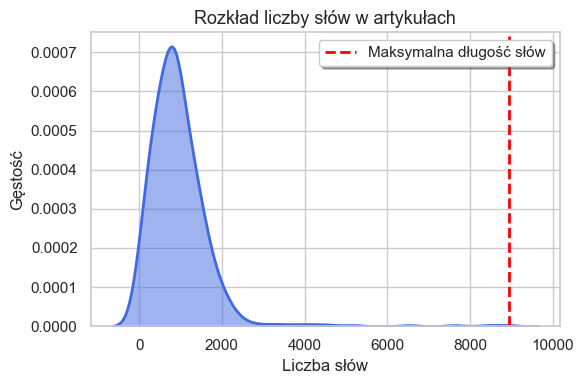

In [55]:
plot_word_count_density(scraped_true)

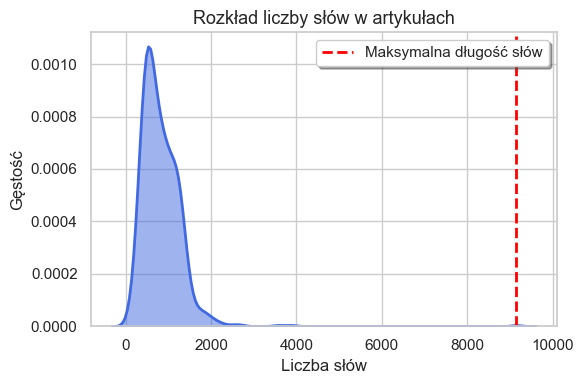

In [56]:
plot_word_count_density(scraped_fake)

Rozkłady również posiadają długi prawy ogon.

In [57]:
get_top_ngrams(scraped_true['text'], top_n = 15, ngram_size=1)

,ngram,frequency
0,said,3130
1,us,1793
2,says,1624
3,trump,1415
4,also,1263
5,one,1261
6,people,1202
7,new,1195
8,year,1064
9,message,999


In [58]:
get_top_ngrams(scraped_fake['text'], top_n = 15, ngram_size=1)

,ngram,frequency
0,said,1678
1,us,1224
2,trump,1199
3,one,1137
4,would,1001
5,new,998
6,people,966
7,advertisement,872
8,also,867
9,state,858


Zestawienia wyglądają podobnie, z jedną różnicą, że w tesktach o niskiej wiarygodności bardzo często występują reklamy (słowo *advertisement*).

In [84]:
get_top_ngrams(scraped_true['text'], top_n = 15, ngram_size=2)

,ngram,frequency
0,margaret brennan,428
1,getty images,286
2,president trump,264
3,cbs news,246
4,new york,239
5,trump administration,220
6,united states,220
7,world cup,210
8,last year,209
9,white house,170


Uwagę zwracają bigramy *sponsor message* oraz *toggle caption*.

In [85]:
phrase = r'\bsponsor message\b' 

scraped_true[scraped_true['text'].str.contains(phrase, case=False, na=False, regex=True)]

,text,label,source_category,publisher


In [86]:
phrase = r'\btoggle caption\b' 

scraped_true[scraped_true['text'].str.contains(phrase, case=False, na=False, regex=True)]

,text,label,source_category,publisher


In [87]:
phrase = r'\bcbs news\b' 

scraped_true[scraped_true['text'].str.contains(phrase, case=False, na=False, regex=True)]

,text,label,source_category,publisher
13,What it means to be a man is a theme in Texas ...,0,news_api,NPR
21,As the globe transitions into an El Niño clima...,0,news_api,CBS News
30,"The Tribeca Festival, originally launched in 2...",0,news_api,CBS News
61,"Israel, Lebanon officials to meet. And, judge ...",0,news_api,NPR
102,Study evaluates how accurate AI is on news and...,0,news_api,CBS News
...,...,...,...,...
591,Voters in San Francisco on Tuesday advanced Sa...,0,news_api,CBS News
592,"CBS News Radio, which provides news programmin...",0,news_api,CBS News
593,"Update: Later on Thursday, President Trump ann...",0,news_api,CBS News
594,"On this ""Face the Nation with Margaret Brennan...",0,news_api,CBS News


Oba wyrażenie są charakterystyczne dla artykułów z *NPR*. Usuniemy je, aby nieco odszumić dane.

In [88]:
scraped_true['text'] = scraped_true['text'].str.replace(r'(?i)\s*\*?(?:sponsor message|toggle caption)\*?\s*', ' ', regex=True)
scraped_true['text'] = scraped_true['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [90]:
get_top_ngrams(scraped_true['text'], top_n = 15, ngram_size=2)

,ngram,frequency
0,margaret brennan,428
1,getty images,286
2,president trump,264
3,cbs news,246
4,new york,239
5,trump administration,220
6,united states,220
7,world cup,210
8,last year,209
9,white house,170


In [91]:
get_top_ngrams(scraped_fake['text'], top_n = 15, ngram_size=2)

,ngram,frequency
0,new york,323
1,united states,278
2,getty images,240
3,president trump,230
4,donald trump,153
5,social media,145
6,los angeles,140
7,white house,134
8,told post,133
9,including fees,130


Bigramy wpisów z nierzetelnych stron wyglądają poprawnie.

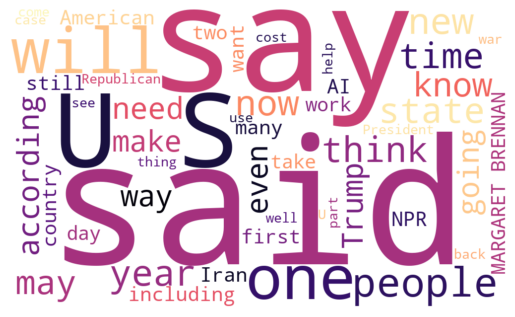

In [92]:
print_word_cloud(scraped_true['text'])

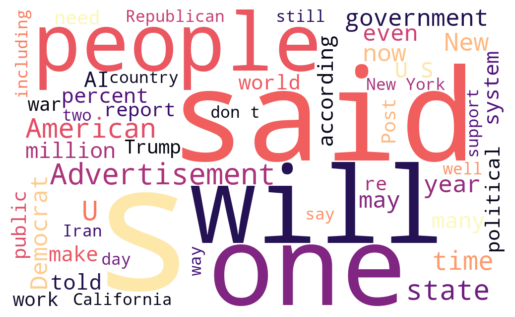

In [93]:
print_word_cloud(scraped_fake['text'])

In [ ]:
# isot_fake.to_csv('../data/processed/isot_fake_preprocessed.csv', index=False)
# isot_true.to_csv('../data/processed/isot_true_preprocessed.csv', index=False)

# scraped_true.to_csv('../data/processed/scraped_true_preprocessed.csv', index=False)
# scraped_fake.to_csv('../data/processed/scraped_fake_preprocessed.csv', index=False)

## Złącznie zbiorów

Po preprocessingu z osobna każdego ze zbiorów, stworzymy jeden duży zbiór danych, który będzie podstawą do dalszej realizacji projektu.

In [96]:
isot_fake['label'] = 1
isot_true['label'] = 0


isot_combined = pd.concat([isot_fake[['text', 'label']], isot_true[['text', 'label']]], ignore_index=True)

In [97]:
isot_combined["source_category"] = "ISOT"

In [98]:
scraped_combined = pd.concat([scraped_fake[['text', 'label', 'source_category']], scraped_true[['text', 'label', 'source_category']]], ignore_index=True)

In [99]:
isot_combined.shape[0], scraped_combined.shape[0]

(44267, 1212)

Nie chcąc, aby stare artykułu ze zbioru *ISOT* zdominowały przyszły zbiór danych, mocno je ograniczymy, jednak chcemy zachować strukturę zbioru - zależy nam na zawarciu tweetów, aby w naszym datasecie krótsze formy wypowiedzi były również reprezentowane.

In [100]:
isot_combined['word_count'] = isot_combined['text'].str.split().str.len()

bins = [0, 200, 800, 100000] # uznajemy, że tweety i krótkie formy mają do 200 słów
labels = ['tweety', 'średnie_artykuły', 'długie_artykuły']

In [101]:
isot_combined['length_cat'] = pd.cut(isot_combined['word_count'], bins=bins, labels=labels)

In [102]:
isot_combined['length_cat'].value_counts()

length_cat
średnie_artykuły    30156
tweety              10539
długie_artykuły      3572
Name: count, dtype: int64

Użyjemy 8000 tesktów ze zbioru *ISOT*.

In [103]:
isot_to_merge, _ = train_test_split(
    isot_combined, 
    train_size=8000, 
    stratify=isot_combined[['label', 'length_cat']], 
    random_state=42
)

In [104]:
isot_to_merge['length_cat'].value_counts()

length_cat
średnie_artykuły    5450
tweety              1905
długie_artykuły      645
Name: count, dtype: int64

In [105]:
isot_to_merge = isot_to_merge.drop(columns=['word_count', 'length_cat']).reset_index(drop=True)

In [106]:
final_dataset = pd.concat([isot_to_merge, scraped_combined], ignore_index=True)
final_dataset = final_dataset.sample(frac=1, random_state=42).reset_index(drop=True) # shuffle 

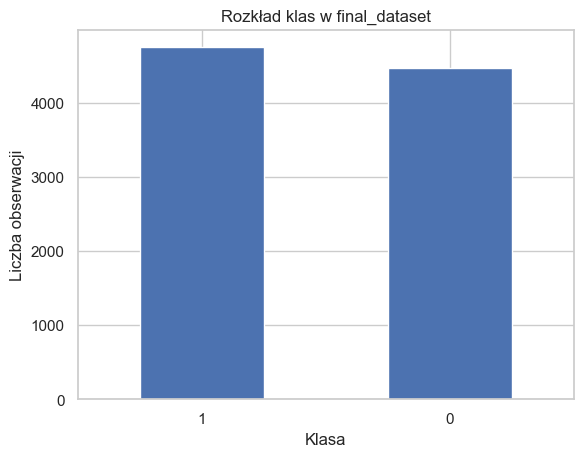

In [107]:
final_dataset['label'].value_counts().plot.bar(
    title='Rozkład klas w final_dataset',
    xlabel='Klasa',
    rot=0,
    ylabel='Liczba obserwacji'
)
plt.show()

Udało się uzyskać zrównoważony zbiór danych.

In [109]:
#final_dataset.to_csv('../data/processed/final_dataset.csv', index=False)